# Part A  – Dataset Understanding & Motivation 


* ### What the dataset represents (domain, context): 
    *   This dataset consists of four CSV files in the domain of global education and human development.It tracks the amount of education people receive in various countries and, in some files, how that education translates into actual learning through learning-adjusted years of schooling. The files collectively span several decades and numerous nations or areas, making it possible to analyze long-term trends like the growth of basic education, shifts in gender gaps, and distinctions between low- and high-income nations.
* ### Why it is interesting or useful: 
    * Because education has a significant impact on social mobility, health outcomes, and economic growth, monitoring these metrics over time aids in assessing a nation's progress and inequality. It is possible to examine how variables like enrollment, learning-adjusted years, and education spending move together, revealing patterns of advancement and stagnation across regions and income groups, thanks to the availability of multiple indicators per country-year. Since the data is split into four related tables, combining on shared keys such as country and year allows for a more comprehensive analysis leading to more insightful patterns than one table alone.
* ### Potential real-world or ML applications: 
    * In practice, this dataset can help with descriptive policy analysis by, for instance, identifying areas where learning and schooling outcomes fall short and measuring educational gaps based on gender or income. It can also be used for machine learning tasks like modeling how changes in spending or student-teacher ratios may impact future education outcomes, clustering countries into similar education profiles, and predicting learning-adjusted years of schooling from economic and demographic indicators.
* ### A link to the dataset source: 
    https://www.kaggle.com/datasets/imtkaggleteam/global-education
    


**Note:** in order to be able to reach the requirements of the assignment (>5000 & 15-20 attributes), I had to combine the four CSVs of the dataset and compute an extra feature. 

# Part B – Data Preprocessing & Cleaning 

## 5.1 Data Inspection

### **Step 1: Data types, shape, and structure**


In [2]:

import pandas as pd

data = pd.read_csv("combined_dataset.csv")

# inspection of the datatypes and structure of the datasets
data.info() #doesnot need display() or print() because info() already prints the output to the console

display(data.head()) 
display(data.tail())

# inspecting the shapes of the datasets and their column names
display(data.shape, data.columns) # gap.shape => (entries, columns) gap.columns => list of column names in gap

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9945 entries, 0 to 9944
Data columns (total 20 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   Entity                                                                                              9945 non-null   object 
 1   Code                                                                                                8853 non-null   object 
 2   Year                                                                                                9945 non-null   int64  
 3   Share of population with no formal education, 1820-2020                                             468 non-null    float64
 4   Share of population with some formal education, 1820-2020                                           468 non-null  

,Entity,Code,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
0,Afghanistan,AFG,1820,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1820
1,Afghanistan,AFG,1825,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1820
2,Afghanistan,AFG,1830,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1830
3,Afghanistan,AFG,1835,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1830
4,Afghanistan,AFG,1840,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1840


,Entity,Code,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
9940,Zimbabwe,ZWE,2015,4.0,96.0,9.17213,10.91966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.74753,NaN,NaN,NaN,20.09179,2010
9941,Zimbabwe,ZWE,2016,NaN,NaN,8.54473,7.76729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.77744,NaN,NaN,NaN,16.31202,2010
9942,Zimbabwe,ZWE,2017,NaN,NaN,9.68927,8.00596,NaN,NaN,NaN,NaN,NaN,NaN,6.35000,-1.68331,NaN,NaN,NaN,17.69523,2010
9943,Zimbabwe,ZWE,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00661,NaN,NaN,NaN,NaN,NaN,2010
9944,Zimbabwe,ZWE,2020,3.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00661,NaN,NaN,NaN,NaN,NaN,2020


(9945, 20)

Index(['Entity', 'Code', 'Year',
       'Share of population with no formal education, 1820-2020',
       'Share of population with some formal education, 1820-2020',
       'Combined gross enrolment ratio for tertiary education, female',
       'Combined gross enrolment ratio for tertiary education, male',
       'Combined total net enrolment rate, secondary, male',
       'Combined total net enrolment rate, secondary, female',
       'Combined total net enrolment rate, primary, female',
       'Combined total net enrolment rate, primary, male',
       'Out-of-school children, adolescents and youth of primary and secondary school age, male (number)',
       'Out-of-school children, adolescents and youth of primary and secondary school age, female (number)',
       'Learning-Adjusted Years of School', 'tertiary_gender_gap',
       'secondary_gender_gap', 'primary_gender_gap', 'total_out_of_school',
       'total_tertiary_enrollment', 'decade'],
      dtype='object')

### **Step 2: Initial summary statistics**

In [3]:

display(data.describe())

display(data.describe(include='all'))

,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
count,9945.000000,468.000000,468.000000,8251.000000,8251.000000,6538.000000,6538.000000,6855.000000,6855.000000,2.577000e+03,2.577000e+03,637.000000,8251.000000,6538.000000,6855.000000,2.574000e+03,8251.000000,9945.000000
mean,1962.159980,22.095108,77.904892,19.170464,16.506685,32.055344,31.498507,53.364914,59.137355,6.412909e+06,7.553630e+06,8.017871,-2.663780,0.556837,5.772440,1.398214e+07,35.677149,1958.472599
std,59.350235,28.451195,28.451195,27.995750,21.995645,35.751953,37.043541,38.688078,37.319553,2.314300e+07,2.773425e+07,2.547377,9.558125,5.908243,12.766902,5.083069e+07,49.434635,58.508633
min,1820.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.400000e+01,3.300000e+01,2.206502,-61.417130,-66.550000,-60.650000,1.650000e+02,0.000000,1820.000000
25%,1920.000000,1.000000,64.850000,0.000000,0.060000,0.140000,0.010000,6.920000,19.710000,1.476800e+04,1.150500e+04,6.024927,-3.296895,-1.123567,-0.010000,2.572000e+04,0.070000,1920.000000
50%,1991.000000,7.000000,93.000000,3.167690,5.653580,12.047725,6.580000,64.800030,74.000000,1.232130e+05,1.027850e+05,8.169077,0.010000,0.010000,1.100000,2.297905e+05,9.270000,1990.000000
75%,2008.000000,35.150000,99.000000,30.156035,27.061165,69.839107,72.712023,90.564715,93.026330,1.084688e+06,1.127516e+06,10.321753,1.110000,1.429128,8.803449,2.239783e+06,57.166905,2000.000000
max,2021.000000,98.200000,100.000000,152.656900,149.406390,100.000000,100.000000,100.000000,99.991820,1.734708e+08,2.121824e+08,12.937873,48.148030,72.520000,90.700000,3.816765e+08,301.809210,2020.000000


,Entity,Code,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
count,9945,8853,9945.000000,468.000000,468.000000,8251.000000,8251.000000,6538.000000,6538.000000,6855.000000,6855.000000,2.577000e+03,2.577000e+03,637.000000,8251.000000,6538.000000,6855.000000,2.574000e+03,8251.000000,9945.000000
unique,241,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,World,OWID_WRL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,81,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1962.159980,22.095108,77.904892,19.170464,16.506685,32.055344,31.498507,53.364914,59.137355,6.412909e+06,7.553630e+06,8.017871,-2.663780,0.556837,5.772440,1.398214e+07,35.677149,1958.472599
std,NaN,NaN,59.350235,28.451195,28.451195,27.995750,21.995645,35.751953,37.043541,38.688078,37.319553,2.314300e+07,2.773425e+07,2.547377,9.558125,5.908243,12.766902,5.083069e+07,49.434635,58.508633
min,NaN,NaN,1820.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.400000e+01,3.300000e+01,2.206502,-61.417130,-66.550000,-60.650000,1.650000e+02,0.000000,1820.000000
25%,NaN,NaN,1920.000000,1.000000,64.850000,0.000000,0.060000,0.140000,0.010000,6.920000,19.710000,1.476800e+04,1.150500e+04,6.024927,-3.296895,-1.123567,-0.010000,2.572000e+04,0.070000,1920.000000
50%,NaN,NaN,1991.000000,7.000000,93.000000,3.167690,5.653580,12.047725,6.580000,64.800030,74.000000,1.232130e+05,1.027850e+05,8.169077,0.010000,0.010000,1.100000,2.297905e+05,9.270000,1990.000000
75%,NaN,NaN,2008.000000,35.150000,99.000000,30.156035,27.061165,69.839107,72.712023,90.564715,93.026330,1.084688e+06,1.127516e+06,10.321753,1.110000,1.429128,8.803449,2.239783e+06,57.166905,2000.000000


## 5.2 Handling Missing Data

### **Step 1: Identifying Missing Values**

In order to be able to choose a strategy for handling missing values, i need to find out how dense this dataset is. Therefore, first step was to calculate the number and percentage of missing values per column.

In [4]:
missing = data.isnull().sum() #.isnull() returns a dataframe of the same shape as data with True for missing values and False for non-missing values, then sum() counts the number of True values in each column, which gives us the number of missing values per column
#by default, the data.isnull().sum() is per column, if we wanted to count missing values per row, we would use data.isnull().sum(axis=1)
display(missing) 
missing_percentage = (missing / len(data)) * 100
print(f"percentage of missing values in each column: {missing_percentage}")
print(f"number of duplicated rows: {data.duplicated().sum()}")


Entity                                                                                                   0
Code                                                                                                  1092
Year                                                                                                     0
Share of population with no formal education, 1820-2020                                               9477
Share of population with some formal education, 1820-2020                                             9477
Combined gross enrolment ratio for tertiary education, female                                         1694
Combined gross enrolment ratio for tertiary education, male                                           1694
Combined total net enrolment rate, secondary, male                                                    3407
Combined total net enrolment rate, secondary, female                                                  3407
Combined total net enrolment rate, pr

percentage of missing values in each column: Entity                                                                                                 0.000000
Code                                                                                                  10.980392
Year                                                                                                   0.000000
Share of population with no formal education, 1820-2020                                               95.294118
Share of population with some formal education, 1820-2020                                             95.294118
Combined gross enrolment ratio for tertiary education, female                                         17.033685
Combined gross enrolment ratio for tertiary education, male                                           17.033685
Combined total net enrolment rate, secondary, male                                                    34.258421
Combined total net enrolment rate, secondary, female       

### **Step 2: Dropping Features with High Percentage of Missinf Values**

Since the dataset contains an extremely high amount of missing vales, some features have to be dropped as their existance is simply meaningless.

After inspecting the results of the above cell, I have decided to drop all the features that have a missing percentage of higher than 70%. This would leave us with features with a max value of missingness to be around 30%. Other methods and techniques shall be explored to handle them further. 


In [5]:

cd = missing_percentage[missing_percentage > 70] # this is a tuple of column names and their missing percentage that are above the threshold
display(cd)
cols_drop = cd.index.tolist() # i want to get a list of the names of the colums cuz that is how i will drop them later, so i get the index of the tuple which is the column name and convert it to a list
print(f"dropping {len(cols_drop)} columns with >70% missing")
data_cleaned = data.drop(columns=cols_drop)

Share of population with no formal education, 1820-2020                                               95.294118
Share of population with some formal education, 1820-2020                                             95.294118
Out-of-school children, adolescents and youth of primary and secondary school age, male (number)      74.087481
Out-of-school children, adolescents and youth of primary and secondary school age, female (number)    74.087481
Learning-Adjusted Years of School                                                                     93.594771
total_out_of_school                                                                                   74.117647
dtype: float64

dropping 6 columns with >70% missing


### **Step 3: Analyzing Missing values per row**

Eventhough i have removed all features with very high missing values, the overall percentage of missing values in the dataset is still considerably high. This leads to the need of exploration of how much of the data is missing per row. 

Missing data per row essentially refers to missing data for a specific country per a certain year, it is worth investigating whether there are any imputation techniques that would replace these missing values with meaningful data without distorting the distribution and accuracy of the dataset

In [6]:

print(f"rows with NO missing values: {data_cleaned.dropna().shape[0]}") # dropna() drops all rows with any missing values, then shape[0] is the number of rows left
print(f"rows with ANY missing values: {data_cleaned.isnull().any(axis=1).sum()}") # when axis = 0, we are looking at columns, when axis = 1, we are looking at rows, so this counts how many rows have any missing values

rows with NO missing values: 4815
rows with ANY missing values: 5130


### **Step 4: Forward-Fill Imputation**

Since the dataset still acquires high missigness (>5%), an imputation technique like Mean/Median/Mode Imputation would not be suitable and would cause very high distortion to the dataset.

After having done some research, i came to the conclusion that the best imputation technique for this dataset would be the forward-fill imputation. this technique means that a missing value is replaced with the most recent previous non-missing value in the dataset. This technique works particularly well for time-series data -like this dataset. Educational indicators exibit temoral continuity, where values in a particular year can be very predictive of the values in the upcoming year. Hence, relying on this technique for this dataset would not distort the distribution much and is a logical approximation, unlike financial data for example. 

It is worth noting that the forward-fill method could cause outdated values if the missing values span many years. However, given that the nature of educational change is gradual, it is a reasonable trade-off compared to other imputation techniques for this matter. 



In [7]:

data_cleaned = data_cleaned.sort_values(['Entity', 'Year'])
data_cleaned = data_cleaned.groupby('Entity', group_keys=False).apply(lambda x: x.ffill())

print("Missing after forward fill:")
print(data_cleaned.isnull().sum()/len(data_cleaned) * 100)


Missing after forward fill:
Entity                                                            0.000000
Code                                                             10.980392
Year                                                              0.000000
Combined gross enrolment ratio for tertiary education, female     6.153846
Combined gross enrolment ratio for tertiary education, male       6.153846
Combined total net enrolment rate, secondary, male               11.111111
Combined total net enrolment rate, secondary, female             11.111111
Combined total net enrolment rate, primary, female                7.833082
Combined total net enrolment rate, primary, male                  7.833082
tertiary_gender_gap                                               6.153846
secondary_gender_gap                                             11.111111
primary_gender_gap                                                7.833082
total_tertiary_enrollment                                         6.1538

/var/folders/00/nt69sw_952986_bg7n7jm2c80000gn/T/ipykernel_58948/3170434756.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_cleaned = data_cleaned.groupby('Entity', group_keys=False).apply(lambda x: x.ffill())
/var/folders/00/nt69sw_952986_bg7n7jm2c80000gn/T/ipykernel_58948/3170434756.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_cleaned = data_cleaned.groupby('Entity', group_keys=False).apply(lambda x: x.ffill())


### **Step 5: Threshold Analysis for Remaining Missing Values**

After forward-fill imputation, remaining missing values indicate data gaps that can't be filled chronologically. This had me examine whether it would be best do drop any year where a country has little data.


In [8]:
perc_missing_per_row = (data_cleaned.isnull().sum(axis=1) / data_cleaned.shape[1]) * 100 # this calculates the percentage of missing values in each row by counting the number of missing values in each row (data.isnull().sum(axis=1)) and dividing by the total number of columns (data.shape[1]) 
print(perc_missing_per_row.describe()) 

thresholds = [0, 10, 20, 30, 40, 50] ###
for threshold in thresholds:
    rows_kept = (perc_missing_per_row <= threshold).sum()
    print(f"Rows with ≤{threshold}% missing: {rows_kept} ({rows_kept/len(data_cleaned)*100:.1f}% of total)")



count    9945.000000
mean        6.602025
std        18.117002
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        78.571429
dtype: float64
Rows with ≤0% missing: 8086 (81.3% of total)
Rows with ≤10% missing: 8657 (87.0% of total)
Rows with ≤20% missing: 8657 (87.0% of total)
Rows with ≤30% missing: 9196 (92.5% of total)
Rows with ≤40% missing: 9196 (92.5% of total)
Rows with ≤50% missing: 9486 (95.4% of total)


### **Step 6: Dropping Rows with Any Missing Values**

After having applied the forward-fill imputation technique, there are still rows that we cannot at all estimate its data and Since there are enough rows with no missing values at all, i decided to drop any row with a missing value. 

Note: any row with a missing code was not dropped as the code feature is an extra feature that relates to the entity and its absence is meaningless.


In [9]:

data_cols = [col for col in data_cleaned.columns if col not in ['Entity', 'Code']] 
data_cleaned = data_cleaned.dropna(subset=data_cols)

# Check missing values in cleaned dataset
print("Remaining missing values:")
display(data_cleaned.isnull().sum())
display(data_cleaned.shape)

Remaining missing values:


Entity                                                             0
Code                                                             571
Year                                                               0
Combined gross enrolment ratio for tertiary education, female      0
Combined gross enrolment ratio for tertiary education, male        0
Combined total net enrolment rate, secondary, male                 0
Combined total net enrolment rate, secondary, female               0
Combined total net enrolment rate, primary, female                 0
Combined total net enrolment rate, primary, male                   0
tertiary_gender_gap                                                0
secondary_gender_gap                                               0
primary_gender_gap                                                 0
total_tertiary_enrollment                                          0
decade                                                             0
dtype: int64

(8657, 14)

## 5.3 Data Cleaning



### **Step 1: Duplicate Detection**



In [10]:

print(f"number of duplicated rows : {data_cleaned.duplicated(subset=['Entity', 'Code', 'Year']).sum()}")

number of duplicated rows : 0


### **Step 2: Standardize formats**

In [11]:


data_cleaned['Entity'] = data_cleaned['Entity'].str.strip()
data_cleaned['Code'] = data_cleaned['Code'].str.strip().str.upper()

# check if year is integer and whether it needs standardization
print(f"year data type is: {data_cleaned['Year'].dtype}")



year data type is: int64


Not much standardization needs to be done to this data

## 5.4 Outlier Detection and Treatment

The following is a function that was provided in the examples code.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(data: pd.DataFrame, variable: str):
    """
    Plots a boxplot and histogram for a given variable to visualize its distribution.

    Args:
        data: The pandas DataFrame containing the data.
        variable: The name of the column (variable) to plot.
    """
    # Create a figure with two subplots that share the x-axis
    f, (ax_box, ax_hist) = plt.subplots(
        nrows=2, 
        sharex=True, 
        gridspec_kw={"height_ratios": (.15, .85)},
        figsize=(8, 6)
    )

    # Add a title for the entire figure
    f.suptitle(f"Distribution of '{variable}'", fontsize=16)

    # Create a boxplot on the top subplot
    sns.boxplot(x=data[variable], ax=ax_box)
    # Create a histogram on the bottom subplot
    sns.histplot(data=data, x=variable, ax=ax_hist, kde=True)

    plt.show()


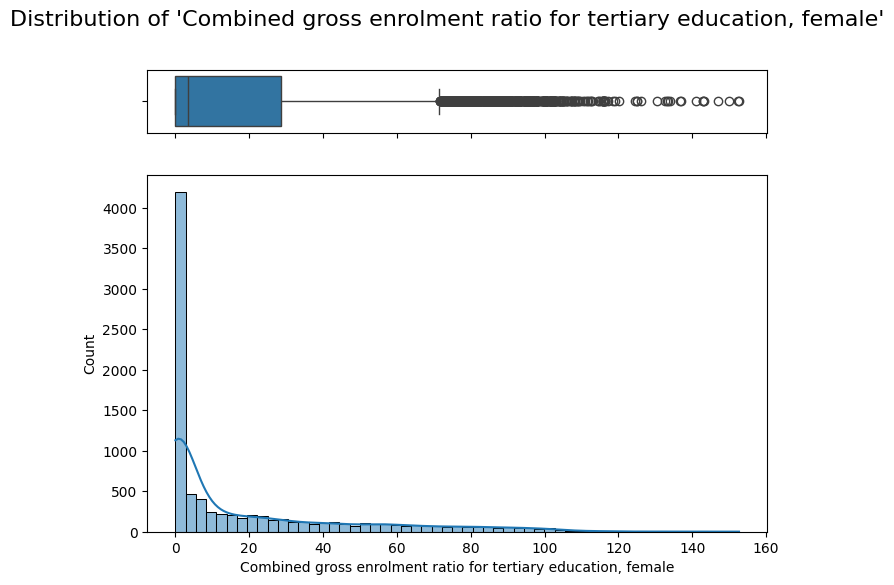

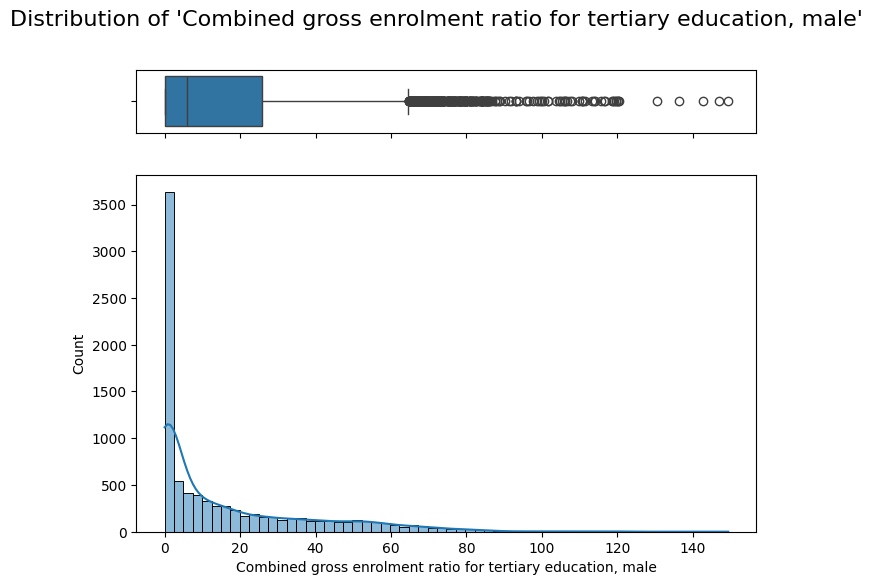

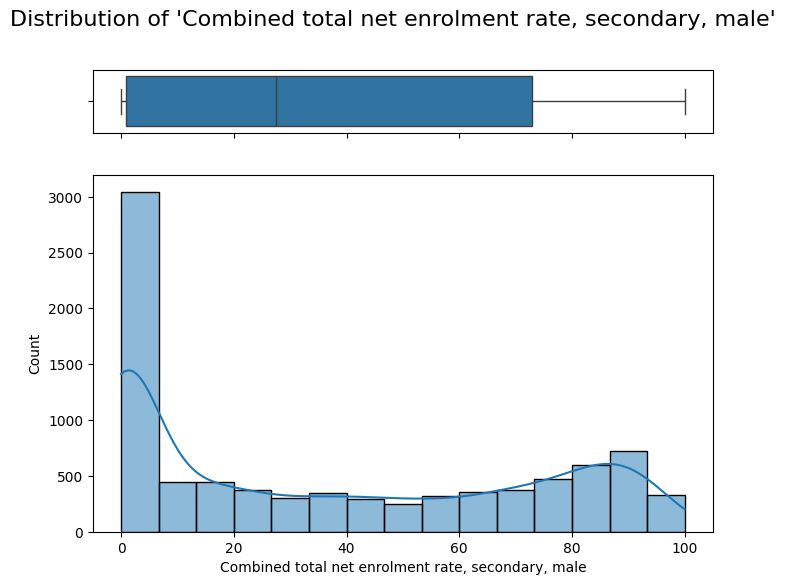

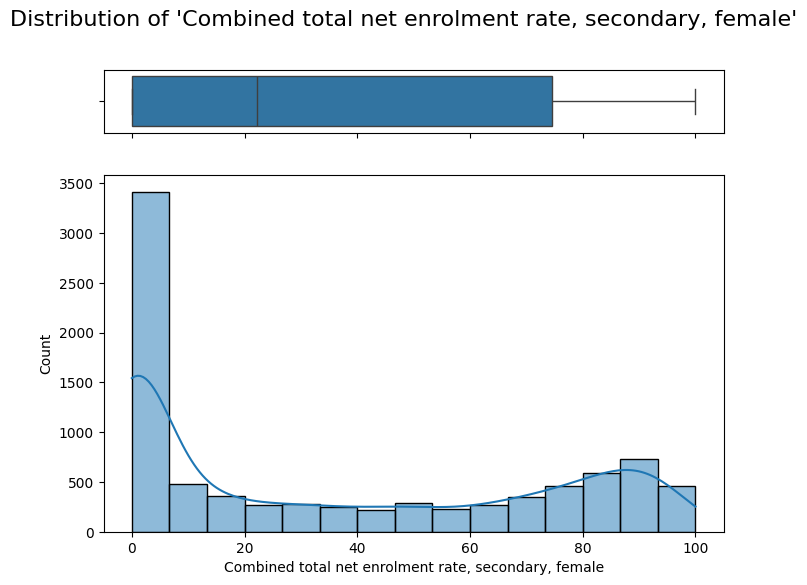

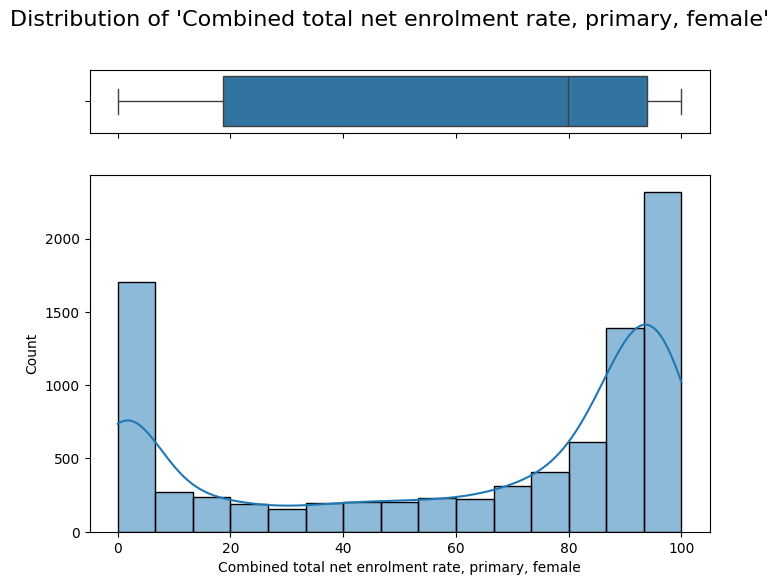

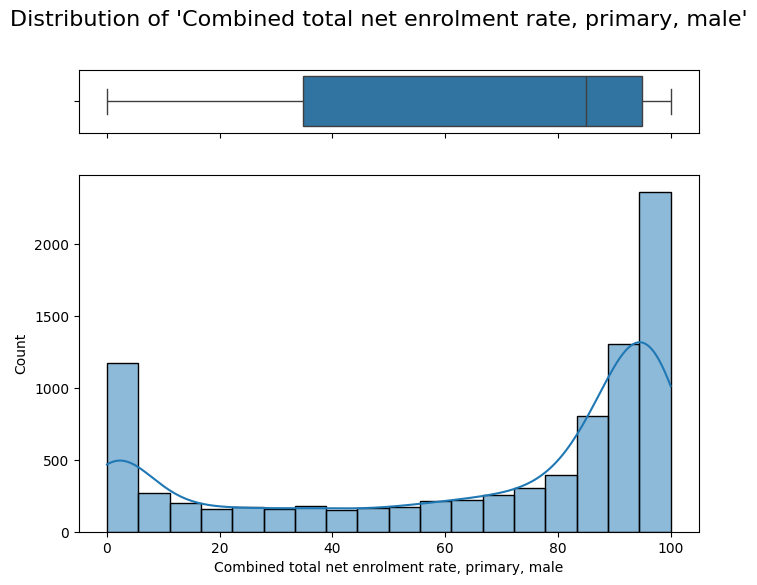

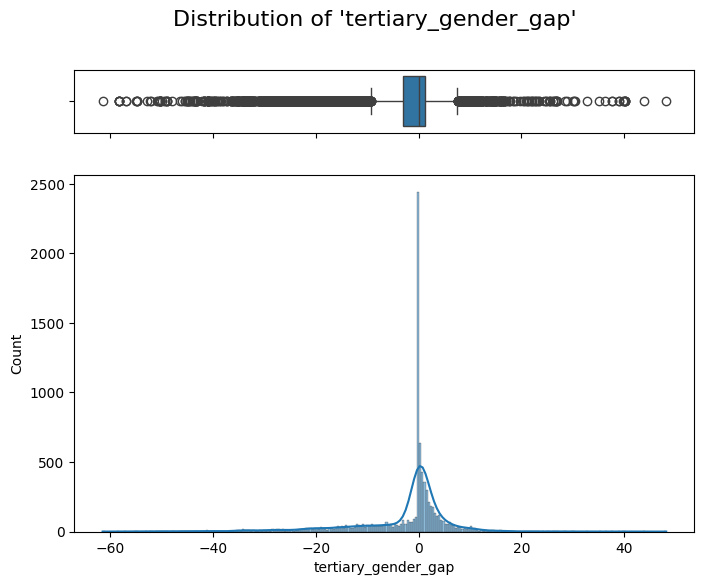

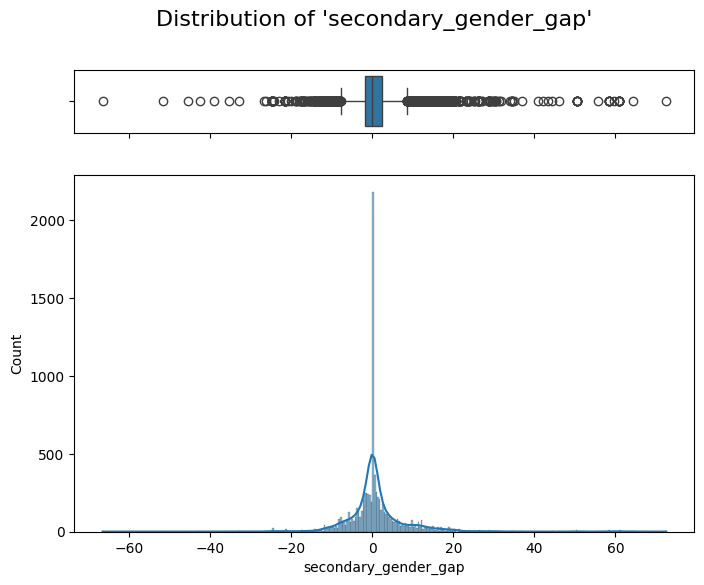

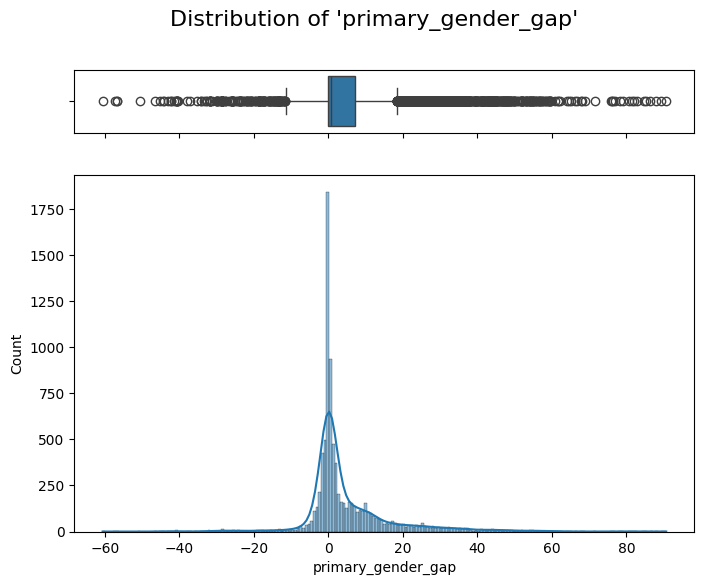

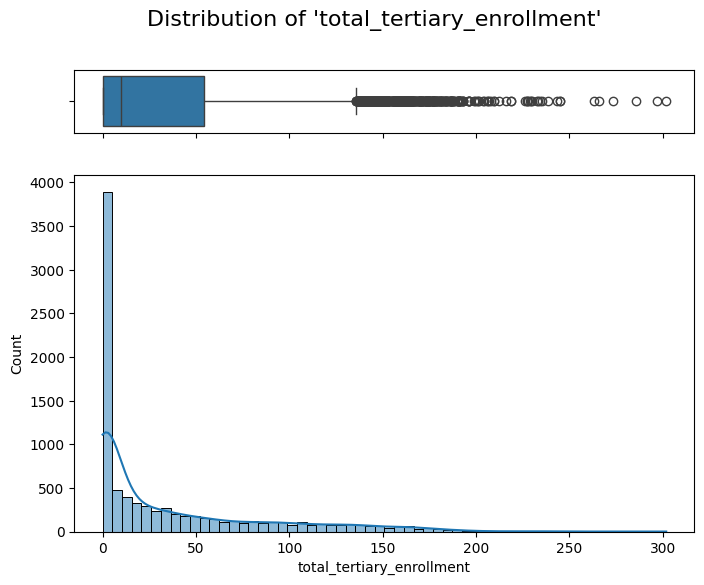

In [13]:
excluded_cols = ['Entity', 'Code', 'Year', 'decade']
cols_to_scale = [col for col in data_cleaned.select_dtypes(include=['float64', 'int64']).columns 
                          if col not in excluded_cols]
for i in cols_to_scale:
    plot_distribution(data_cleaned, i)

The distribution analysis verifies that rather than being mistakes, the outliers in this dataset are actual extremes of the world's educational systems. Low enrollment outliers are indicative of past data or crisis situations, whereas high enrollment outliers (>100%) show educational centers with international students. Real societal disparities are captured by gender gap outliers in both directions. These extreme values are kept in place for the following reasons: they accurately reflect human development variation, eliminating them would reduce the predictive range of the model, they make up a small portion of the 5,000+ observations and do not skew distributions, they contain important policy-relevant data regarding educational success and failure. Maintaining outliers is consistent with the domain knowledge that educational systems vary significantly between nations and eras.

## 5.5 Feature Engineering and Selection



**Step 1: Drop irrelevant features**

**Code Removal**: Country codes are redundant with Entity and add no additional information, so i will drop them to reduce dimensionality.

In [14]:

feature_to_drop = [
    'Code'
]

data_cleaned = data_cleaned.drop(columns=feature_to_drop)


display(data_cleaned.columns)
display(data_cleaned.shape)
display(data_cleaned.head())

Index(['Entity', 'Year',
       'Combined gross enrolment ratio for tertiary education, female',
       'Combined gross enrolment ratio for tertiary education, male',
       'Combined total net enrolment rate, secondary, male',
       'Combined total net enrolment rate, secondary, female',
       'Combined total net enrolment rate, primary, female',
       'Combined total net enrolment rate, primary, male',
       'tertiary_gender_gap', 'secondary_gender_gap', 'primary_gender_gap',
       'total_tertiary_enrollment', 'decade'],
      dtype='object')

(8657, 13)

,Entity,Year,"Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male",tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_tertiary_enrollment,decade
0,Afghanistan,1820,0.0,0.01,0.01,0.0,0.0,0.01,0.01,0.01,0.01,0.01,1820
1,Afghanistan,1825,0.0,0.01,0.01,0.0,0.0,0.01,0.01,0.01,0.01,0.01,1820
2,Afghanistan,1830,0.0,0.01,0.01,0.0,0.0,0.01,0.01,0.01,0.01,0.01,1830
3,Afghanistan,1835,0.0,0.01,0.01,0.0,0.0,0.01,0.01,0.01,0.01,0.01,1830
4,Afghanistan,1840,0.0,0.01,0.01,0.0,0.0,0.01,0.01,0.01,0.01,0.01,1840


**Step 2: Encode categorical features**

The only categorical feature in the dataset is the country names. Encoding this feature does not make sense as there are a lot of features and one-hot encoding would increase the dimentionality by a lot. 

**Step 3: derived features**

These have already been computed during the dataset merging phase (see `merging_dataset.ipynb`). 

## Part C -  Exploratory Data Analysis (EDA)

In [15]:
data_cleaned.dtypes

Entity                                                            object
Year                                                               int64
Combined gross enrolment ratio for tertiary education, female    float64
Combined gross enrolment ratio for tertiary education, male      float64
Combined total net enrolment rate, secondary, male               float64
Combined total net enrolment rate, secondary, female             float64
Combined total net enrolment rate, primary, female               float64
Combined total net enrolment rate, primary, male                 float64
tertiary_gender_gap                                              float64
secondary_gender_gap                                             float64
primary_gender_gap                                               float64
total_tertiary_enrollment                                        float64
decade                                                             int64
dtype: object

In [16]:

feature = 'tertiary_gender_gap'

print(f"mean: {data_cleaned[feature].mean():.4f}")
print(f"median: {data_cleaned[feature].median():.4f}")
print(f"mode: {data_cleaned[feature].mode().values[0]:.4f}")

print(f"variance: {data_cleaned[feature].var():.4f}")
print(f"standard deviation: {data_cleaned[feature].std():.4f}")
print(f"range: {data_cleaned[feature].max() - data_cleaned[feature].min():.4f}")
print(f"IQR: {data_cleaned[feature].quantile(0.75) - data_cleaned[feature].quantile(0.25):.4f}")
print(f"Min: {data_cleaned[feature].min():.4f}")
print(f"Max: {data_cleaned[feature].max():.4f}")

print(f"Q1: {data_cleaned[feature].quantile(0.25):.4f}")
print(f"Q2: {data_cleaned[feature].quantile(0.50):.4f}")
print(f"Q3: {data_cleaned[feature].quantile(0.75):.4f}")

mean: -2.5969
median: 0.0100
mode: 0.0100
variance: 94.2659
standard deviation: 9.7091
range: 109.5652
IQR: 4.2240
Min: -61.4171
Max: 48.1480
Q1: -2.9598
Q2: 0.0100
Q3: 1.2642


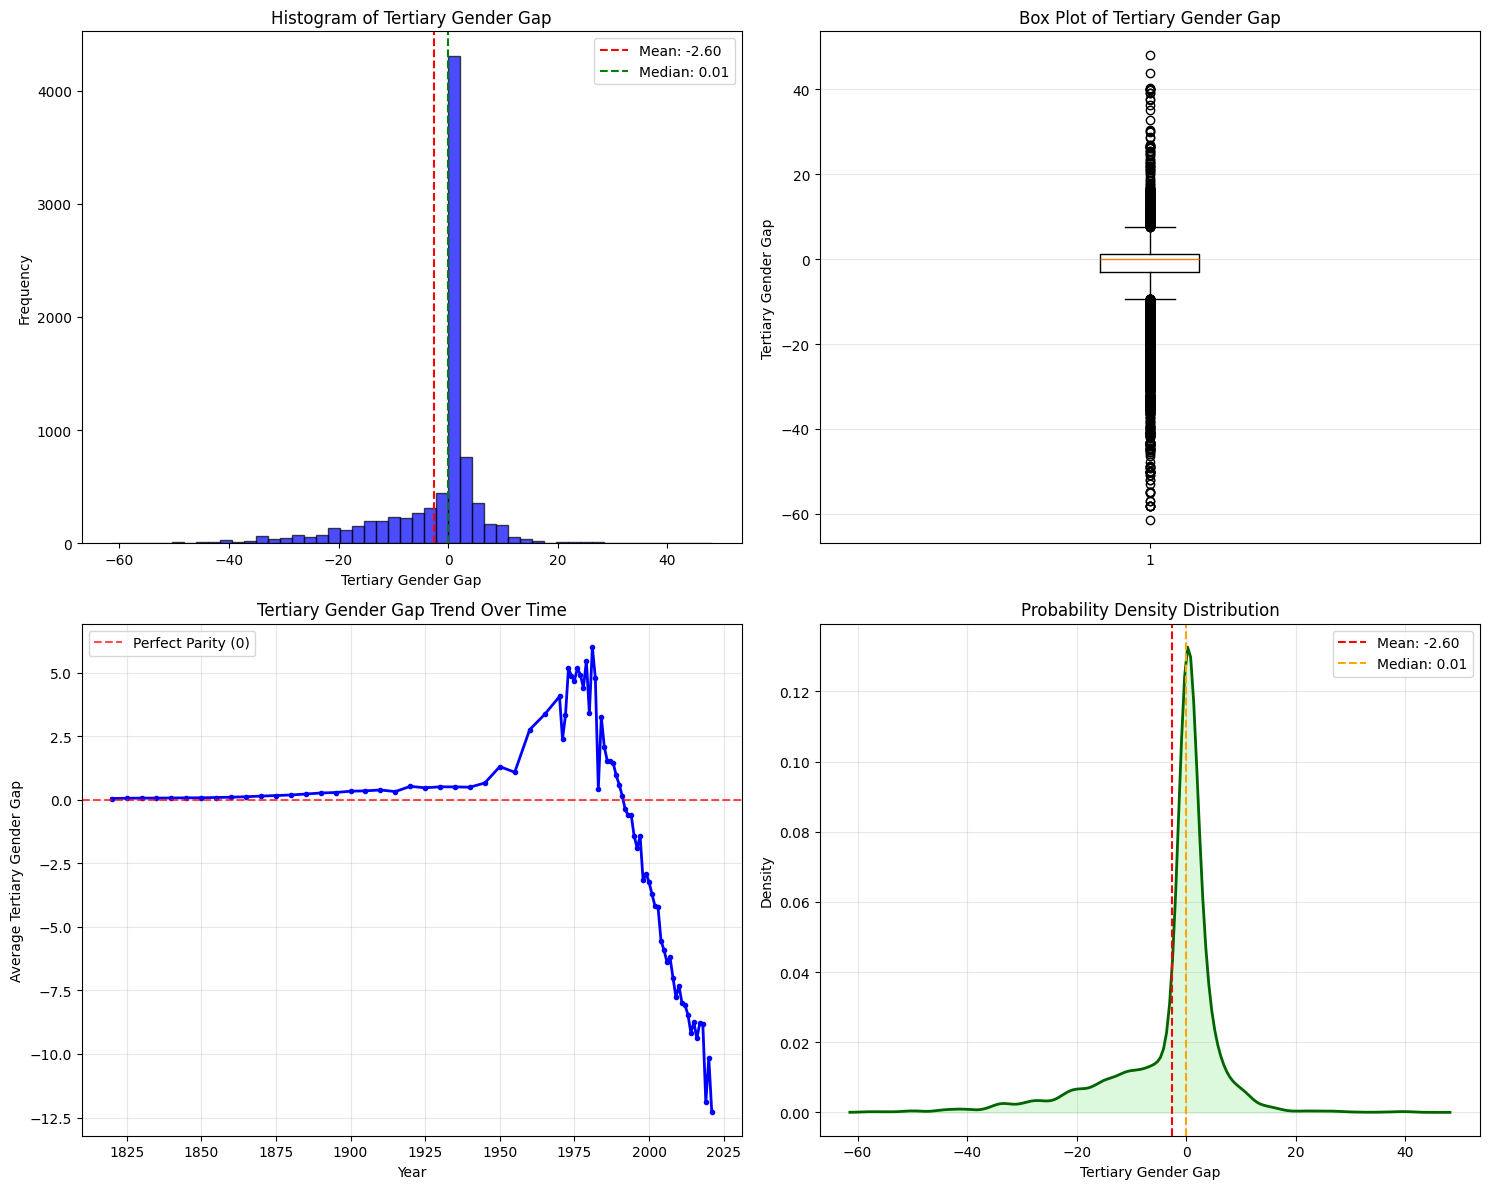

In [17]:


import numpy as np
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram 
axes[0, 0].hist(data_cleaned[feature].dropna(), bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].axvline(data_cleaned[feature].mean(), color='red', linestyle='--', label=f'Mean: {data_cleaned[feature].mean():.2f}')
axes[0, 0].axvline(data_cleaned[feature].median(), color='green', linestyle='--', label=f'Median: {data_cleaned[feature].median():.2f}')
axes[0, 0].set_title('Histogram of Tertiary Gender Gap')
axes[0, 0].set_xlabel('Tertiary Gender Gap')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Box Plot
axes[0, 1].boxplot(data_cleaned[feature].dropna(), vert=True)
axes[0, 1].set_ylabel('Tertiary Gender Gap')
axes[0, 1].set_title('Box Plot of Tertiary Gender Gap')
axes[0, 1].grid(axis='y', alpha=0.3)

# Time Series:
yearly_avg = data_cleaned.groupby('Year')[feature].mean()
axes[1, 0].plot(yearly_avg.index, yearly_avg.values, linewidth=2, color='blue', marker='o', markersize=3)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Perfect Parity (0)')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Tertiary Gender Gap')
axes[1, 0].set_title('Tertiary Gender Gap Trend Over Time')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Density Plot
density_data = data_cleaned[feature].dropna()
density = gaussian_kde(density_data)
xs = np.linspace(density_data.min(), density_data.max(), 200)
axes[1, 1].plot(xs, density(xs), linewidth=2, color='darkgreen')
axes[1, 1].fill_between(xs, density(xs), alpha=0.3, color='lightgreen')
axes[1, 1].axvline(data_cleaned[feature].mean(), color='red', linestyle='--', label=f'Mean: {data_cleaned[feature].mean():.2f}')
axes[1, 1].axvline(data_cleaned[feature].median(), color='orange', linestyle='--', label=f'Median: {data_cleaned[feature].median():.2f}')
axes[1, 1].set_xlabel('Tertiary Gender Gap')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Probability Density Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization Justifications and Interpretations

**1. Histogram with Mean/Median Lines**

**Why Chosen:** This histogram illustrates the frequency distribution of gender gaps with mean and median lines to evaluate symmetry.

**Interpretation:** This plot shows a bell-shaped, symmetric distribution with an almost identitical mean and median. This result shows that the majority of countries over the years have reached or are getting closer to gender parity in tertiary enrollment. 

**Insights Gained:** Since the graph shows a concentration at 0, it is safe to say that the global trend supports equality for both genders in education, and that the historical male dominance has drastically dimished. However, the symmetric tails indicate that there exists some contries that favor males over females and vice versa.



**2. Box Plot**

**Why Chosen:** For rapidly identifying data spread and extreme values, the box plot offers a condensed statistical summary that displays quartiles, median, and outliers.

**Interpretation:** The box plot shows that there is widespread gender parity in tertiary education, with 50% of data falling within a fairly narrow IQR centered near 0. But outliers go both ways. Female-advantage outliers (negative values up to -60) are more extreme than male-advantage outliers (positive values up to about +40-50), indicating that, when they do occur, modern gender imbalances tend to favor women more.

**Insights Gained:** The compact IQR validates decades of gender equity efforts by showing that the majority of countries have attained near-parity. While bidirectional gender gaps still exist in some situations, the asymmetric outlier distribution shows that female overrepresentation in tertiary education is more common in contemporary extreme cases. To comprehend both policy accomplishments (countries attaining high female enrollment) and persistent barriers (countries with remaining male advantage), these outliers require more examination.


**3. Time Series - Gender Gap Trend Over Years**

**Why Chosen:** This line plot illustrates how policies and investments change over time during the dataset's whole historical period, revealing temporal patterns in gender equity.

**Interpretation:** The Line graph shows a complicated three-phase pattern: relative gender parity from the early 1800s till the 1950s (values near zero), then a dramatic spike in male advantage peaking around 1990 (positive values reaching roughly +5) then finally a sharp reversal after 2000 that resulted in a significant female advantage in recent years (negative values reaching -10 to -12). This suggests that rather than reaching equilibrium at parity, the current tertiary education landscape has changed from male-dominated to female-dominated systems.

**Insights Gained:** This pattern shows that initiatives to promote gender equity have completely reversed past gaps rather than just closing them. While the sharp fall after 2000 indicates that programs encouraging female access to school have been extraordinarily successful, possibly overcorrecting, the mid-20th century spike in male enrollment probably reflects post-war educational growth that disproportionately benefited men. Rapid change is indicated by the steep slope of recent decades, which raises significant policy problems regarding male underrepresentation in higher education and whether current trends are a new type of gender imbalance that has to be addressed.



**4. Probability Density Distribution (KDE)**

**Why Chosen:** Compared to histograms, which are susceptible to bin width decisions, the KDE offers a smooth, continuous representation of the probability distribution that makes the underlying form more apparent.

**Interpretation:** With the peak nearly perfectly aligned with the median (0.01) and the mean somewhat negative (-2.60), the smooth curve displays a characteristic bell shape (Gaussian distribution) centered extremely near to zero. The symmetric tails stretch equally in both directions, suggesting that individual country-year observations naturally range around this central tendency even while the aggregate data indicates near-parity. Because it is a derived measure (male rate minus female rate) that benefits from the Central Limit Theorem, the distribution's normality stands out as the sole feature in the dataset displaying this pattern.

**Insights Gained:** When looking at all nations and years combined, the symmetric, normal distribution with zero at its center shows that the global education system has stabilized around gender parity. Additionally, the normalcy implies that huge gender inequalities in either direction are not signs of skewed underlying processes, but rather are true outliers and that gender gaps fluctuate naturally around parity rather than exhibiting systematic directional bias throughout the entire dataset. 

## 6.2 Bivariate and Multivariate Analysis



### Correlation Analysis

**Question:** How strongly do different education metrics relate to each other? 

,"Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male",tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_tertiary_enrollment
"Combined gross enrolment ratio for tertiary education, female",1.00,0.95,0.81,0.82,0.58,0.52,-0.73,-0.20,-0.26,0.99
"Combined gross enrolment ratio for tertiary education, male",0.95,1.00,0.82,0.82,0.61,0.56,-0.48,-0.13,-0.26,0.98
"Combined total net enrolment rate, secondary, male",0.81,0.82,1.00,0.98,0.79,0.74,-0.47,-0.09,-0.31,0.82
"Combined total net enrolment rate, secondary, female",0.82,0.82,0.98,1.00,0.79,0.71,-0.51,-0.29,-0.34,0.83
"Combined total net enrolment rate, primary, female",0.58,0.61,0.79,0.79,1.00,0.95,-0.28,-0.10,-0.32,0.60
"Combined total net enrolment rate, primary, male",0.52,0.56,0.74,0.71,0.95,1.00,-0.24,-0.03,-0.00,0.54
tertiary_gender_gap,-0.73,-0.48,-0.47,-0.51,-0.28,-0.24,1.00,0.28,0.17,-0.63
secondary_gender_gap,-0.20,-0.13,-0.09,-0.29,-0.10,-0.03,0.28,1.00,0.25,-0.17
primary_gender_gap,-0.26,-0.26,-0.31,-0.34,-0.32,-0.00,0.17,0.25,1.00,-0.26
total_tertiary_enrollment,0.99,0.98,0.82,0.83,0.60,0.54,-0.63,-0.17,-0.26,1.00


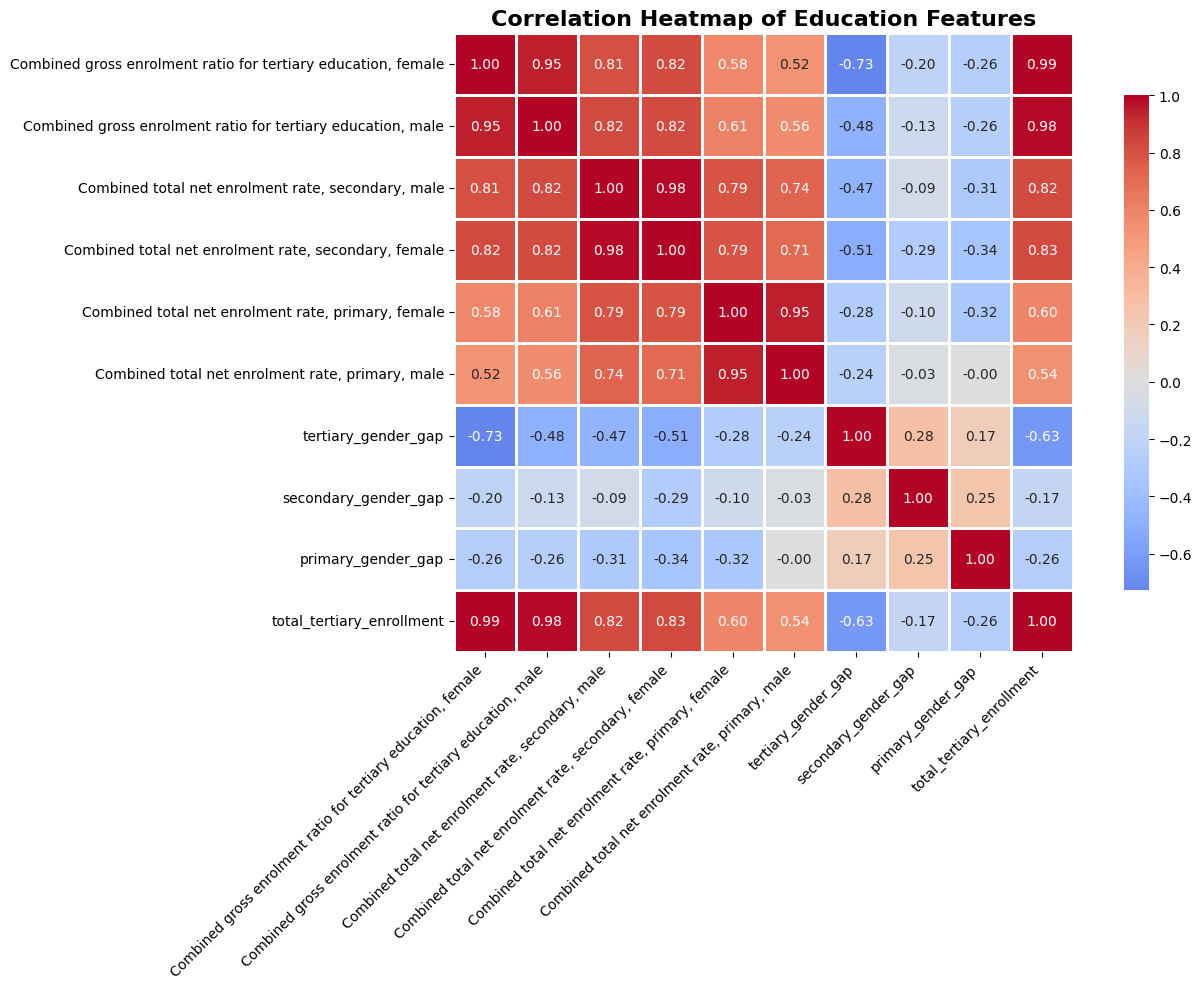

In [18]:

numerical_features = data_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features = [col for col in numerical_features if col not in ['Year', 'decade']]

correlation_matrix = data_cleaned[numerical_features].corr()

display(correlation_matrix.round(2))

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Education Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Insights Gained:** Three major trends can be seen in the correlation heatmap. First, global gender parity in education is confirmed by the virtually equal enrollment rates of males and females at the same educational level (correlations over 0.95). Second, with correlations of 0.74-0.82 across neighboring levels, there is a definite "educational ladder" effect, meaning that finishing one level predicts moving on to the next. However, this effect is much weaker for non-adjacent levels, such as primary to tertiary (only 0.52-0.58). Third, there is little link between gender inequalities and total enrollment rates (correlations less than 0.5), demonstrating that nations can attain gender equality independently of enrollment levels—equity and access are separate problems that need different solutions.

### Scatter Plot Analysis

**Question:** is a strong foundation in basic (primary) education predict higher education achievement?

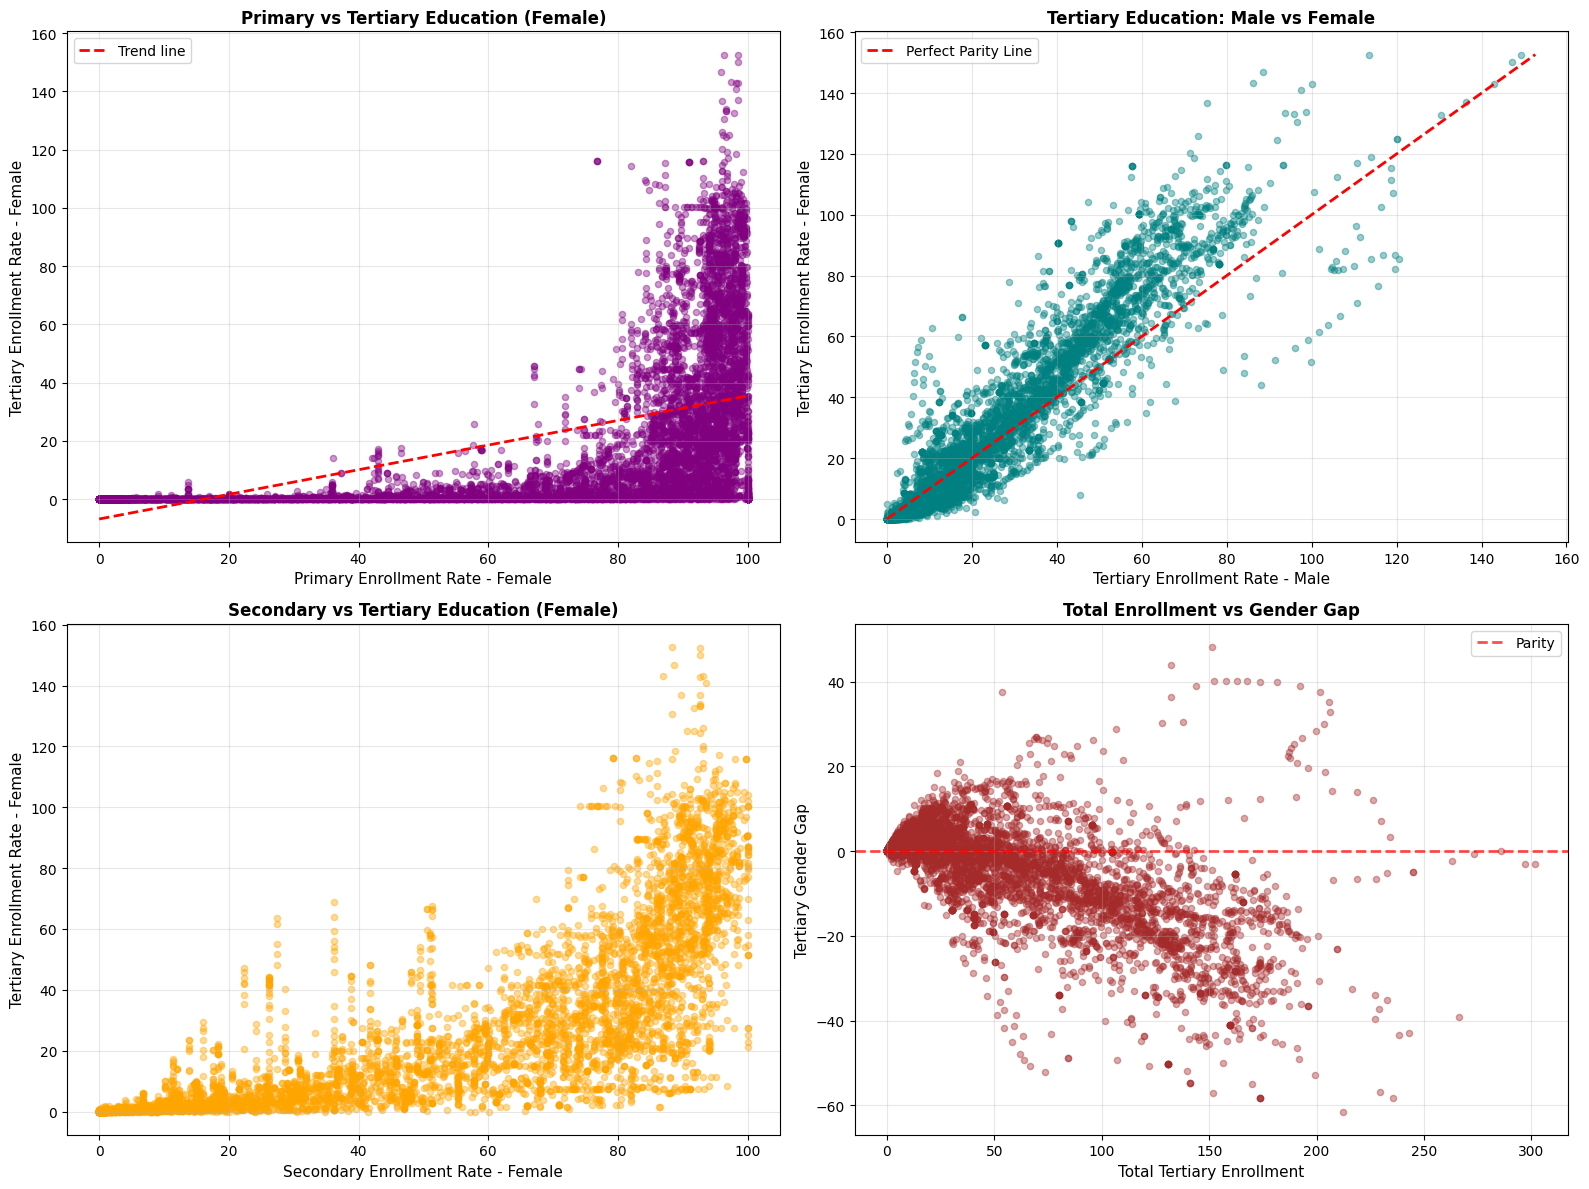

In [229]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter 1: Primary Female vs Tertiary Female
axes[0, 0].scatter(data_cleaned['Combined total net enrolment rate, primary, female'], 
                   data_cleaned['Combined gross enrolment ratio for tertiary education, female'],
                   alpha=0.4, s=20, color='purple')
axes[0, 0].set_xlabel('Primary Enrollment Rate - Female', fontsize=11)
axes[0, 0].set_ylabel('Tertiary Enrollment Rate - Female', fontsize=11)
axes[0, 0].set_title('Primary vs Tertiary Education (Female)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(data_cleaned['Combined total net enrolment rate, primary, female'].dropna(), 
               data_cleaned['Combined gross enrolment ratio for tertiary education, female'].dropna(), 1)
p = np.poly1d(z)
x_trend = np.linspace(data_cleaned['Combined total net enrolment rate, primary, female'].min(), 
                      data_cleaned['Combined total net enrolment rate, primary, female'].max(), 100)
axes[0, 0].plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend line')
axes[0, 0].legend()

# Scatter 2: Tertiary Male vs Tertiary Female
axes[0, 1].scatter(data_cleaned['Combined gross enrolment ratio for tertiary education, male'], 
                   data_cleaned['Combined gross enrolment ratio for tertiary education, female'],
                   alpha=0.4, s=20, color='teal')
axes[0, 1].set_xlabel('Tertiary Enrollment Rate - Male', fontsize=11)
axes[0, 1].set_ylabel('Tertiary Enrollment Rate - Female', fontsize=11)
axes[0, 1].set_title('Tertiary Education: Male vs Female', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
# Add equality line
max_val = max(data_cleaned['Combined gross enrolment ratio for tertiary education, male'].max(),
              data_cleaned['Combined gross enrolment ratio for tertiary education, female'].max())
axes[0, 1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Parity Line')
axes[0, 1].legend()

# Scatter 3: Secondary Female vs Tertiary Female
axes[1, 0].scatter(data_cleaned['Combined total net enrolment rate, secondary, female'], 
                   data_cleaned['Combined gross enrolment ratio for tertiary education, female'],
                   alpha=0.4, s=20, color='orange')
axes[1, 0].set_xlabel('Secondary Enrollment Rate - Female', fontsize=11)
axes[1, 0].set_ylabel('Tertiary Enrollment Rate - Female', fontsize=11)
axes[1, 0].set_title('Secondary vs Tertiary Education (Female)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Scatter 4: Tertiary Gender Gap vs Total Tertiary Enrollment
axes[1, 1].scatter(data_cleaned['total_tertiary_enrollment'], 
                   data_cleaned['tertiary_gender_gap'],
                   alpha=0.4, s=20, color='brown')
axes[1, 1].set_xlabel('Total Tertiary Enrollment', fontsize=11)
axes[1, 1].set_ylabel('Tertiary Gender Gap', fontsize=11)
axes[1, 1].set_title('Total Enrollment vs Gender Gap', fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Parity')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


**Insights Gained:** Success in tertiary education is not well predicted by primary schooling alone. With a correlation of just 0.58, the association is weak even if the primary-to-tertiary scatter plot displays a positive trend. Tertiary enrollment rates vary greatly among nations with nearly universal primary enrollment (95–100%); some exceed 150%, while others remain below 20%. With a correlation of 0.82 to tertiary enrollment, secondary education is a far more powerful predictor. This suggests that although primary education is important, it is insufficient for success in higher education. Whether or whether students make a smooth transition from secondary school—where the actual pipeline to university is established—is the crucial issue. Primary enrollment alone is not as important as other elements like secondary school quality, labor market demands, and economic development.

### Pair Plot Analysis

**Question:** Does the pipeline of secondary to tertiary education function similarly for men and women?

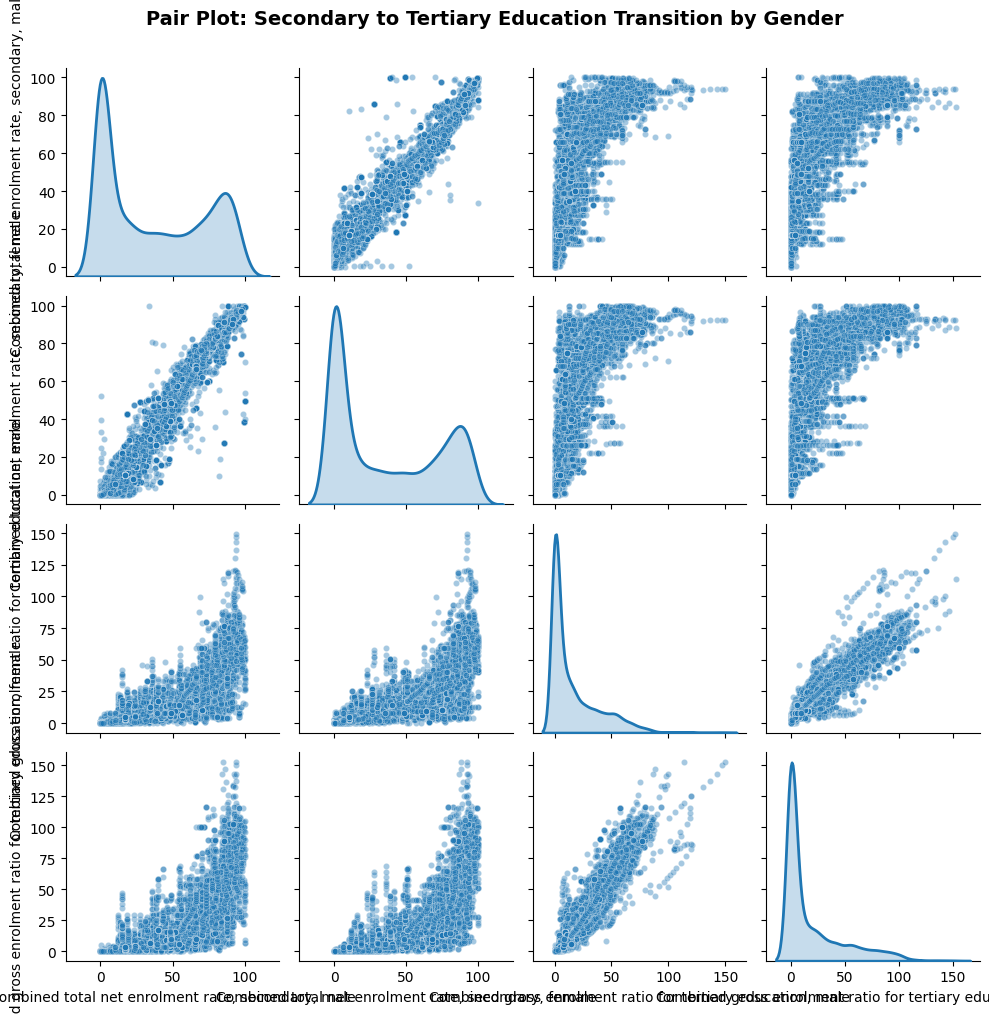

Pair plot generated for 8657 observations across 4 features.


In [19]:
pairplot_features = [
    'Combined total net enrolment rate, secondary, male',
    'Combined total net enrolment rate, secondary, female',
    'Combined gross enrolment ratio for tertiary education, male',
    'Combined gross enrolment ratio for tertiary education, female'
]

# Create pair plot
pairplot_data = data_cleaned[pairplot_features].dropna()
sns.pairplot(pairplot_data, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20}, 
             diag_kws={'linewidth': 2}, corner=False)
plt.suptitle('Pair Plot: Secondary to Tertiary Education Transition by Gender', 
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Pair plot generated for {len(pairplot_data)} observations across {len(pairplot_features)} features.")



**Insights Gained:** The secondary-to-tertiary shift is equally robust for both genders, as the pair plot demonstrates. At every level, the enrollment distributions for men and women are almost the same in form, exhibiting right-skewed tertiary distributions and bimodal secondary patterns. Strong positive relationships between secondary and tertiary enrollment for both genders are shown by the scatter plots, suggesting that they progress through the educational system in parallel but separate ways. Males and girls do not compete for tertiary slots; instead, each gender's advancement is determined by its own secondary enrollment rate. This demonstrates that secondary school serves as a bottleneck for both genders equally.

### Grouped Box Plot Analysis

**Question:** How have enrollment rates and gender gaps evolved over the decades? 

/var/folders/00/nt69sw_952986_bg7n7jm2c80000gn/T/ipykernel_27780/1945579376.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=decade_data, x='decade_bin', y='Combined gross enrolment ratio for tertiary education, female',
/var/folders/00/nt69sw_952986_bg7n7jm2c80000gn/T/ipykernel_27780/1945579376.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=decade_data, x='decade_bin', y='tertiary_gender_gap',
/var/folders/00/nt69sw_952986_bg7n7jm2c80000gn/T/ipykernel_27780/1945579376.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

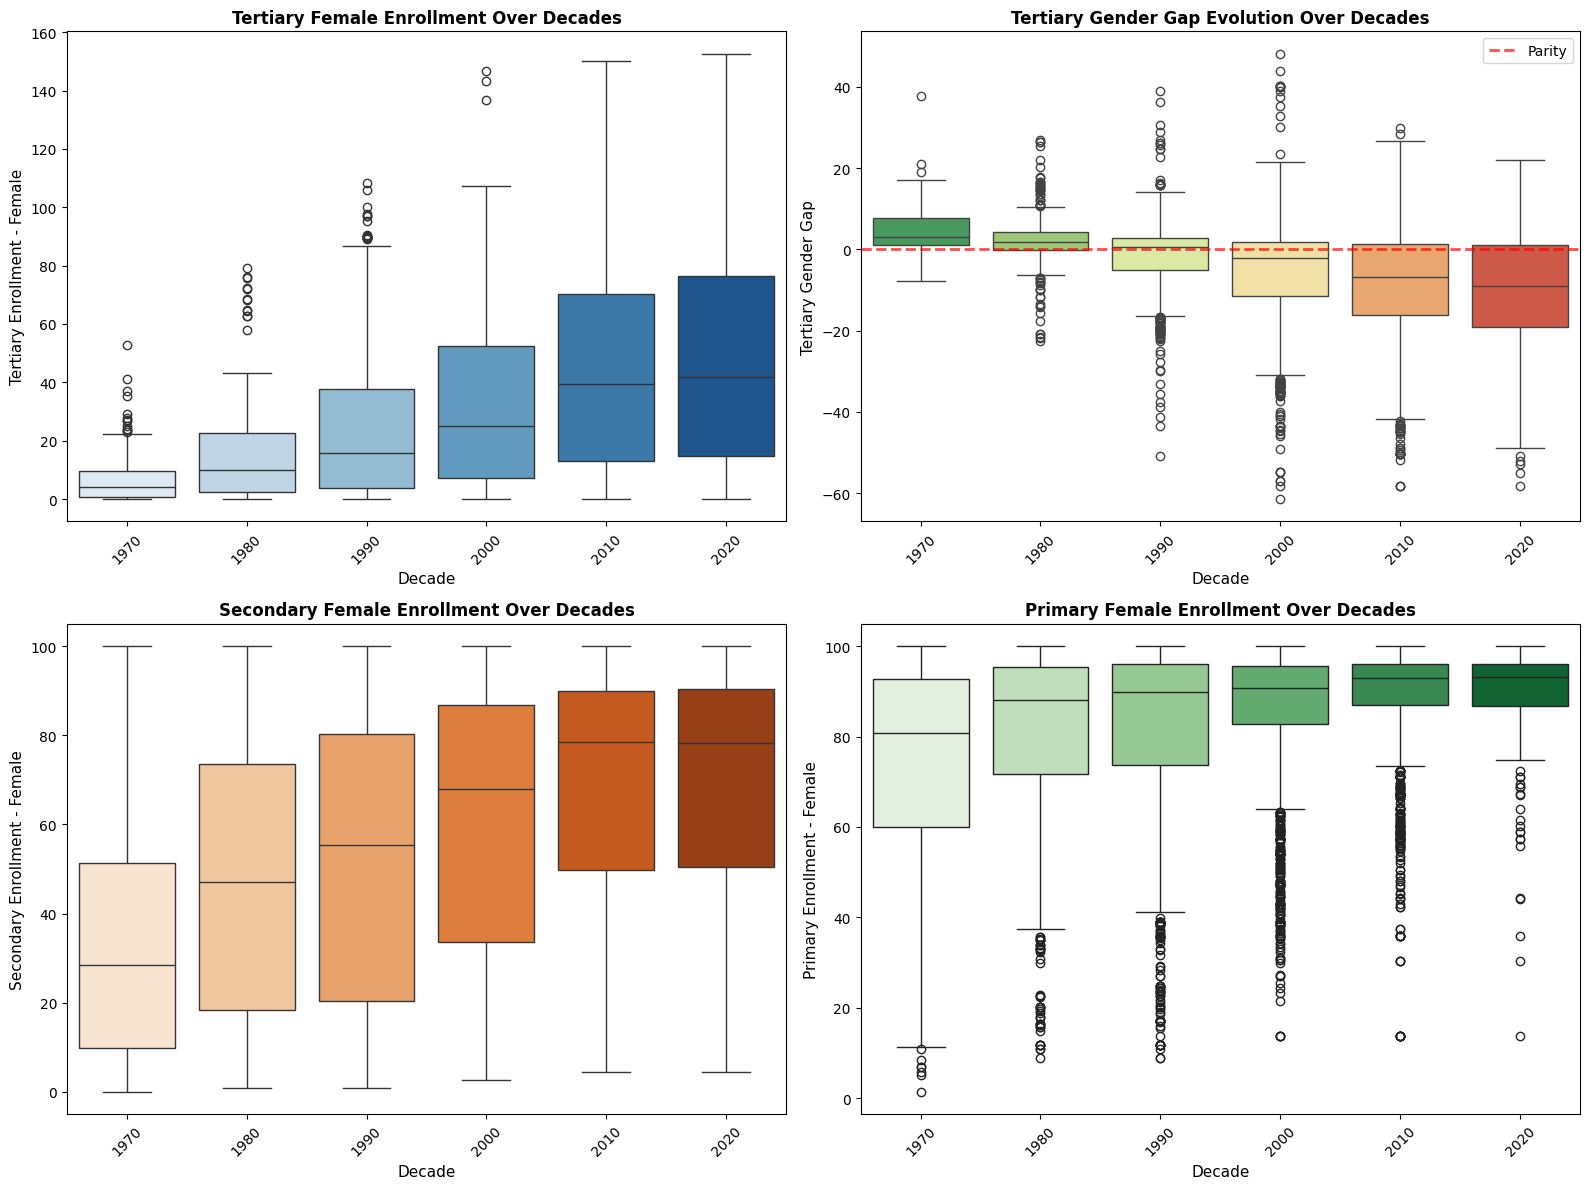

In [ ]:
# Create decade bins 
data_cleaned['decade_bin'] = (data_cleaned['Year'] // 10) * 10

# avoid very early periods
decade_data = data_cleaned[data_cleaned['decade_bin'] >= 1970].copy()

# Create grouped box plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Tertiary Female Enrollment by Decade
sns.boxplot(data=decade_data, x='decade_bin', y='Combined gross enrolment ratio for tertiary education, female', 
            ax=axes[0, 0], palette='Blues')
axes[0, 0].set_xlabel('Decade', fontsize=11)
axes[0, 0].set_ylabel('Tertiary Enrollment - Female', fontsize=11)
axes[0, 0].set_title('Tertiary Female Enrollment Over Decades', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Tertiary Gender Gap by Decade
sns.boxplot(data=decade_data, x='decade_bin', y='tertiary_gender_gap', 
            ax=axes[0, 1], palette='RdYlGn_r')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Parity')
axes[0, 1].set_xlabel('Decade', fontsize=11)
axes[0, 1].set_ylabel('Tertiary Gender Gap', fontsize=11)
axes[0, 1].set_title('Tertiary Gender Gap Evolution Over Decades', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# Plot 3: Secondary Female Enrollment by Decade
sns.boxplot(data=decade_data, x='decade_bin', y='Combined total net enrolment rate, secondary, female', 
            ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_xlabel('Decade', fontsize=11)
axes[1, 0].set_ylabel('Secondary Enrollment - Female', fontsize=11)
axes[1, 0].set_title('Secondary Female Enrollment Over Decades', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Primary Female Enrollment by Decade
sns.boxplot(data=decade_data, x='decade_bin', y='Combined total net enrolment rate, primary, female', 
            ax=axes[1, 1], palette='Greens')
axes[1, 1].set_xlabel('Decade', fontsize=11)
axes[1, 1].set_ylabel('Primary Enrollment - Female', fontsize=11)
axes[1, 1].set_title('Primary Female Enrollment Over Decades', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Clean up temporary column
data_cleaned.drop('decade_bin', axis=1, inplace=True)


**Insights Gained:** By the 1970s, primary enrollment had quickly reached nearly universal coverage (~95%) and had stabilized. The median for secondary enrollment increased from around 30% to about 85%, however there are still differences between nations. Globally, tertiary female enrollment has been steadily increasing as access has expanded. Though outliers indicate that certain nations are still opposed to gender fairness, the gender gap has drastically changed in recent decades, moving from male advantage in the 1970s and 1980s to near-parity and female advantage. While secondary and tertiary progress is still uneven across nations, this reflects the successful implementation of policies in elementary education and gender equity.